# 01 — Data Audit
Quick sanity check on the raw dataset before any modeling.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.config import RAW_DATA, TARGET, TRAIN_YEARS, TEST_YEAR

## 1. Load & Basic Shape

In [2]:
df = pd.read_csv(RAW_DATA, low_memory=False)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (47033, 76)


,Year,ZIP,Avg Fire Risk Score,Avg PPC,CAT Cov A Fire - Incurred Losses,CAT Cov A Fire - Number of Claims,CAT Cov A Smoke - Incurred Losses,CAT Cov A Smoke - Number of Claims,CAT Cov C Fire - Incurred Losses,CAT Cov C Fire - Number of Claims,...,average_household_size,educational_attainment_bachelor_or_higher,poverty_status,housing_occupancy_number,housing_value,year_structure_built,housing_vacancy_number,median_monthly_housing_costs,owner_occupied_housing_units,renter_occupied_housing_units
0,2018,90003,1.00,1.000,0,0,0,0,0,0,...,4.03,2294.0,18743.0,18349.0,547600.0,18349.0,715.0,1609.0,4692.0,12942.0
1,2018,90004,0.42,1.075,0,0,0,0,0,0,...,2.44,11822.0,10994.0,26046.0,1457200.0,26046.0,2311.0,1847.0,4011.0,19724.0
2,2018,90005,0.51,1.060,0,0,0,0,0,0,...,2.18,7582.0,9463.0,19357.0,1084400.0,19357.0,1880.0,1651.0,1572.0,15905.0


## 2. Year Coverage

In [3]:
print('Rows per year:')
print(df['Year'].value_counts().sort_index())
print(f'\nUnique ZIPs: {df["ZIP"].nunique():,}')

Rows per year:
Year
2018    10071
2019     9818
2020    13800
2021    13344
Name: count, dtype: int64

Unique ZIPs: 2,251


## 3. Target Column — Earned Premium

In [4]:
print(df[TARGET].describe())
print(f'\nNulls: {df[TARGET].isnull().sum()}')
print(f'Negative values: {(df[TARGET] < 0).sum()}')

count    4.703300e+04
mean     5.079100e+05
std      1.455284e+06
min     -5.590000e+02
25%      2.842000e+03
50%      4.420700e+04
75%      2.648910e+05
max      3.627053e+07
Name: Earned Premium, dtype: float64

Nulls: 0
Negative values: 7


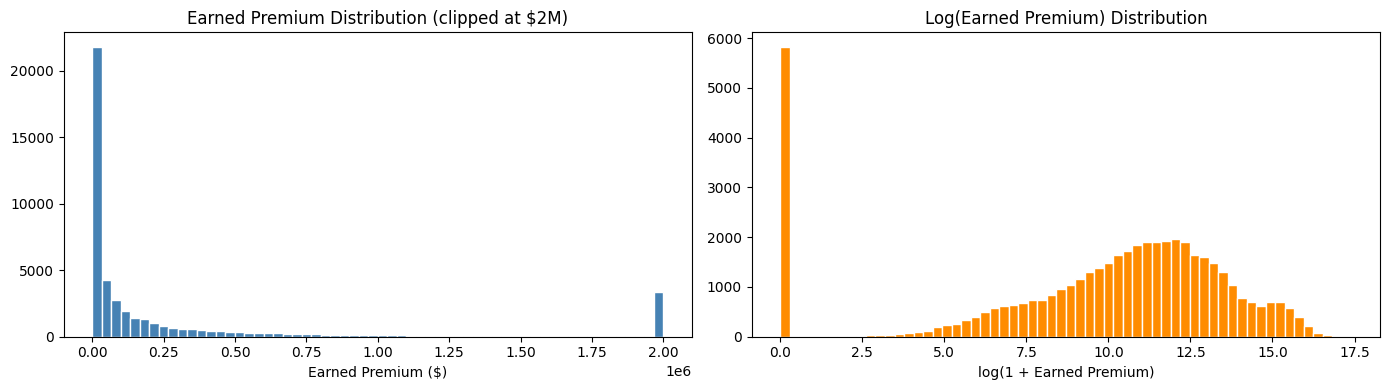

Saved → results/figures/premium_distribution.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Raw distribution
axes[0].hist(df[TARGET].clip(upper=2e6), bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Earned Premium Distribution (clipped at $2M)')
axes[0].set_xlabel('Earned Premium ($)')

# Log distribution
import numpy as np
log_vals = np.log1p(df[TARGET].clip(lower=0))
axes[1].hist(log_vals, bins=60, color='darkorange', edgecolor='white')
axes[1].set_title('Log(Earned Premium) Distribution')
axes[1].set_xlabel('log(1 + Earned Premium)')

plt.tight_layout()
plt.savefig('../results/figures/premium_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/figures/premium_distribution.png')

## 4. Fire Risk Score

In [6]:
print(df['Avg Fire Risk Score'].describe())
print(f'Nulls: {df["Avg Fire Risk Score"].isnull().sum()}')

count    47033.000000
mean         0.833192
std          0.896709
min         -0.210000
25%          0.110000
50%          0.510000
75%          1.190000
max          4.000000
Name: Avg Fire Risk Score, dtype: float64
Nulls: 0


## 5. Missing Value Summary

In [7]:
nulls = df.isnull().sum()
nulls_pct = (nulls / len(df) * 100).round(1)
missing = pd.DataFrame({'null_count': nulls, 'null_pct': nulls_pct})
missing = missing[missing['null_count'] > 0].sort_values('null_pct', ascending=False)
print(f'Columns with missing values: {len(missing)}')
missing.head(20)

Columns with missing values: 42


,null_count,null_pct
FIRE_NUM,47033,100.0
COMPLEX_ID,46973,99.9
COMPLEX_NA,46925,99.8
COMMENTS,44999,95.7
INC_NUM,39227,83.4
CONT_DATE,39164,83.3
avg_tmin_c,39118,83.2
avg_tmax_c,39118,83.2
station,39118,83.2
tot_prcp_mm,39118,83.2


## 6. Confirm Train/Test Split Sizes

In [8]:
train = df[df['Year'].isin(TRAIN_YEARS)]
test  = df[df['Year'] == TEST_YEAR]
print(f'Train (2018-2020): {len(train):,} rows')
print(f'Test  (2021):      {len(test):,} rows')
print('\n✅ Data audit complete — ready for feature engineering')

Train (2018-2020): 33,689 rows
Test  (2021):      13,344 rows

✅ Data audit complete — ready for feature engineering
